# Build Compound Event Catalog - Inland

Build the copula-joint design catalog from reviewed USGS streamflow records and direct AORC SST rainfall members. 

1. Source inventory: show driver libraries and marginal evidence
2. Extract POT events
3. Audit co-occurrence
4. Fit the copula
5. Sample AND-labeled design events
6. Produce Resilience-Design catalogue of 500 events

In [1]:
import sys
from pathlib import Path

notebook_root = Path.cwd().resolve()
location_root = notebook_root.parent
repo_root = location_root.parents[1]
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))
config_yaml = location_root / "config.yaml"

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from IPython.display import display

from pyextremes import get_extremes
import pyvinecopulib as pvc

from design_events.utils import load_runtime
from study_location import define_location
from design_events.utils import build_paths
from design_events.build_events.workflow import build_usgs_streamflow_event_members
from design_events.build_events.probability import build_joint_design_catalog
from design_events.build_events.workflow import select_resilience_stress_training_set
from design_events.build_events.workflow import write_wflow_sfincs_handoff_manifest
from design_events.collect_sources.usgs_streamgages import collect_usgs_streamflow_records
from design_events import plotting as P
from design_events.build_events.workflow import assign_severity_bands

pd.set_option("display.max_columns", 80)
plt.style.use("seaborn-v0_8-whitegrid")

definition = define_location(location_root / "config.yaml")
runtime_config = definition.config
runtime_paths = build_paths(runtime_config)
config, paths = load_runtime(config_yaml)
location_name = paths["location_name"]

resilience_stress_training = {
    "target_event_count": 500,
    "max_mild_fraction": 0.2,
    "severity_band_fractions": {
        "mild": 0.05,
        "common": 0.28,
        "significant": 0.28,
        "rare": 0.12,
        "extreme": 0.27,
    },
    "benchmark_return_period_years": [10, 50, 100, 500],
    "rainfall_heavy_fraction": 0.1,
    "wet_soil_fraction": 0.1,
}
config["resilience_stress_training"] = resilience_stress_training
config.setdefault("events", {})["target_event_count"] = resilience_stress_training["target_event_count"]


## Stage 1 - Source inventory

Start with the driver sources before fitting anything. Every catalog row must trace to a reviewed USGS discharge record, a rainfall member, and an explicit pairing policy.


In [2]:
dependence = config["event_catalog"]["dependence"]
cooccurrence = dependence["cooccurrence"]
pairing = config["event_catalog"].get("pairing", {})

pot_quantile = float(cooccurrence.get("threshold_quantile", 0.95))
decluster_window_hours = float(cooccurrence.get("decluster_window_hours", 120))
min_peak_distance = pd.Timedelta(hours=decluster_window_hours)
cooccurrence_window = pd.Timedelta(hours=float(cooccurrence.get("pairing_window_hours", 72)))

copula_seed = int(dependence.get("copula_seed", 42))
target_design_events = int(resilience_stress_training["target_event_count"])
benchmark_return_periods = resilience_stress_training["benchmark_return_period_years"]

streamflow_csv = paths["usgs_streamgages_root"] / "streamflow_records.csv"
rainfall_csv = paths["aorc_sst_rainfall_members_csv"]
soil_moisture_csv = paths["nwm_soil_moisture_csv"]
output_catalog_csv = paths["catalog_root"] / "copula_design_event_catalog.csv"

source_inventory = pd.DataFrame([
    {
        "driver": "streamflow",
        "source": "USGS reviewed active streamgages",
        "role": "inland frequency axis and streamflow analogs",
        "pairing_policy": pairing.get("streamflow", {}).get("strategy"),
        "path": str(streamflow_csv),
        "status": "complete" if streamflow_csv.exists() else "missing",
    },
    {
        "driver": "rainfall",
        "source": "Direct AORC SST",
        "role": "pluvial compound partner and rainfall member library",
        "pairing_policy": pairing.get("rainfall", {}).get("strategy"),
        "path": str(rainfall_csv),
        "status": "complete" if rainfall_csv.exists() else "missing",
    },
    {
        "driver": "soil_moisture",
        "source": "NWM retrospective",
        "role": "antecedent hydrologic state attached after copula sampling",
        "pairing_policy": pairing.get("soil_moisture", {}).get("strategy"),
        "path": str(soil_moisture_csv),
        "status": "complete" if soil_moisture_csv.exists() else "missing",
    },
])

display(source_inventory)
display(pd.Series({
    "location": location_name,
    "pot_quantile": pot_quantile,
    "decluster_window_hours": decluster_window_hours,
    "pairing_window_hours": cooccurrence_window / pd.Timedelta(hours=1),
    "copula_seed": copula_seed,
    "target_design_events": target_design_events,
    "benchmark_return_periods": benchmark_return_periods,
}, name="event_catalog_parameters"))


,driver,source,role,pairing_policy,path,status
0,streamflow,USGS reviewed active streamgages,inland frequency axis and streamflow analogs,coherent_streamgage_network_event,/home/grahamhults/projects/Flood-RM/locations/...,complete
1,rainfall,Direct AORC SST,pluvial compound partner and rainfall member l...,inland_rainfall_pairing_priority,/home/grahamhults/projects/Flood-RM/locations/...,complete
2,soil_moisture,NWM retrospective,antecedent hydrologic state attached after cop...,inland_antecedent_moisture_pairing,/home/grahamhults/projects/Flood-RM/locations/...,complete


location                            greensboro
pot_quantile                              0.95
decluster_window_hours                   120.0
pairing_window_hours                      72.0
copula_seed                                  2
target_design_events                       500
benchmark_return_periods    [10, 50, 100, 500]
Name: event_catalog_parameters, dtype: object

## Stage 2 - Streamgage-network POT evidence

### 2.1 Driver Member Libraries

The streamflow return period is one driver axis, while rainfall-heavy SST members and wet antecedent states remain available for compound-event selection.


,driver,source,status,member_rows,value_column
0,streamflow,USGS reviewed streamgages,complete,NaN,NaN
1,rainfall,Direct AORC SST,complete,440.0,mean_precip_mm
2,antecedent soil moisture,NWM retrospective,complete,2566240.0,SOILSAT_TOP


,member_id,source,member_file,storm_start,storm_end,duration_hours,rank,annual_rank,mean_precip_mm,max_precip_mm,min_precip_mm,precip_units,potential_method,centroid_lon,centroid_lat,historical_centroid_lon,historical_centroid_lat,transposed_centroid_lon,transposed_centroid_lat,transposition_offset_lon,transposition_offset_lat,transposition_region_id
0,rainfall_greensboro_72h_rank0001,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2018-09-14T18:00:00,2018-09-17T18:00:00,72,1,1,237.784069,329.100005,178.900003,mm,moving_footprint_max_mean,-79.677013,35.699372,-79.750412,36.050386,-79.677013,35.699372,0.073399,-0.351014,greensboro-inland-review-required
1,rainfall_greensboro_72h_rank0002,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,1996-09-03T12:00:00,1996-09-06T12:00:00,72,2,1,208.376101,223.600003,194.000003,mm,moving_footprint_max_mean,-79.710345,36.566004,-79.639047,36.178398,-79.710345,36.566004,-0.071298,0.387606,greensboro-inland-review-required
2,rainfall_greensboro_72h_rank0003,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2008-08-25T12:00:00,2008-08-28T12:00:00,72,3,1,195.605369,251.400004,156.600002,mm,moving_footprint_max_mean,-80.076997,35.899364,-79.747985,36.103707,-80.076997,35.899364,-0.329012,-0.204343,greensboro-inland-review-required
3,rainfall_greensboro_72h_rank0004,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,1990-10-10T06:00:00,1990-10-13T06:00:00,72,4,1,183.937564,194.100003,167.000002,mm,moving_footprint_max_mean,-80.210325,35.899364,-79.842741,36.136921,-80.210325,35.899364,-0.367584,-0.237557,greensboro-inland-review-required
4,rainfall_greensboro_72h_rank0005,aorc_sst,/home/grahamhults/projects/Flood-RM/locations/...,2002-10-11T00:00:00,2002-10-14T00:00:00,72,5,1,182.975612,194.100003,172.400003,mm,moving_footprint_max_mean,-79.210365,36.199352,-79.611221,36.055074,-79.210365,36.199352,0.400856,0.144278,greensboro-inland-review-required


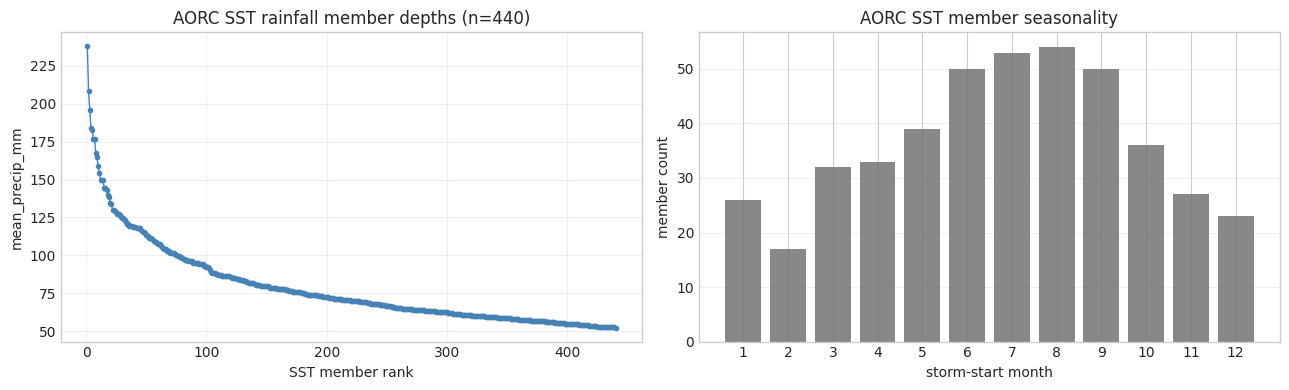

In [3]:
rainfall_members = pd.read_csv(rainfall_csv)
soil_moisture_members = pd.read_csv(soil_moisture_csv) if soil_moisture_csv.exists() else pd.DataFrame()
if not soil_moisture_members.empty:
    soil_moisture_members.attrs["source_file"] = str(soil_moisture_csv)

rainfall_time_column = next(column for column in ["storm_start", "storm_date", "time"] if column in rainfall_members)
rainfall_value_column = next(
    column for column in ["mean_precip_mm", "max_precip_mm", "mean", "max"] if column in rainfall_members
)
soil_value_column = next(
    (column for column in ["SOILSAT_TOP", "SOIL_M", "soil_moisture"] if column in soil_moisture_members),
    None,
)

driver_library_summary = pd.DataFrame([
    {"driver": "streamflow", "source": "USGS reviewed streamgages", "status": source_inventory.loc[0, "status"]},
    {
        "driver": "rainfall",
        "source": "Direct AORC SST",
        "status": source_inventory.loc[1, "status"],
        "member_rows": len(rainfall_members),
        "value_column": rainfall_value_column,
    },
    {
        "driver": "antecedent soil moisture",
        "source": "NWM retrospective",
        "status": source_inventory.loc[2, "status"],
        "member_rows": len(soil_moisture_members),
        "value_column": soil_value_column,
    },
])

display(driver_library_summary)
P.plot_rainfall_member_distribution(rainfall_members);
rainfall_members.head(5)


### 2.2 Raw USGS Streamflow and Rainfall Records

The streamflow conditioning axis is collapsed to the reviewed network maximum at each timestamp. Rainfall is represented by the direct AORC SST member library using the configured rainfall value column.


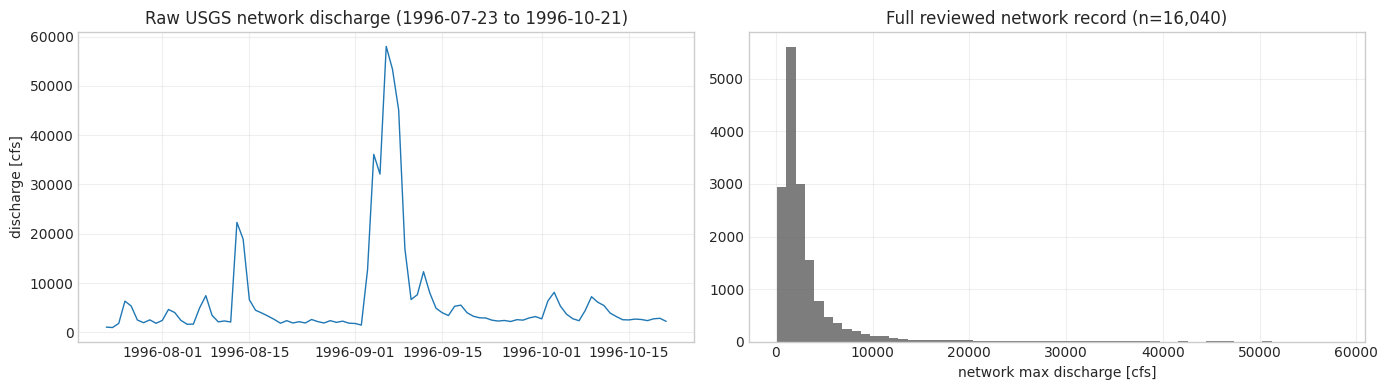

streamflow_rows                   16040
streamflow_start    1979-02-01 00:00:00
streamflow_end      2022-12-31 00:00:00
rainfall_rows                       440
rainfall_start      1979-02-23 00:00:00
rainfall_end        2022-11-25 00:00:00
Name: driver_record_windows, dtype: object

In [4]:
streamflow_records = pd.read_csv(streamflow_csv, parse_dates=["time"], dtype={"site_no": str})
df_streamflow = streamflow_records.groupby("time")["discharge_cfs"].max().sort_index().to_frame()

rainfall_records = rainfall_members.copy()
rainfall_records[rainfall_time_column] = pd.to_datetime(rainfall_records[rainfall_time_column], errors="coerce")
rainfall_records[rainfall_value_column] = pd.to_numeric(rainfall_records[rainfall_value_column], errors="coerce")
df_rainfall = (
    rainfall_records.dropna(subset=[rainfall_time_column, rainfall_value_column])
    .groupby(rainfall_time_column)[rainfall_value_column]
    .max()
    .rename("precip_mm")
    .sort_index()
    .to_frame()
)

network_streamflow_records = df_streamflow.reset_index().assign(site_no="network_max")
network_streamflow_records = network_streamflow_records[["site_no", "time", "discharge_cfs"]]

peak_time = df_streamflow["discharge_cfs"].idxmax()
window_slice = (peak_time - pd.Timedelta(days=45), peak_time + pd.Timedelta(days=45))
window = df_streamflow.loc[window_slice[0]:window_slice[1], "discharge_cfs"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(window.index, window.values, lw=1.0)
axes[0].set_title(f"Raw USGS network discharge ({window_slice[0]:%Y-%m-%d} to {window_slice[1]:%Y-%m-%d})")
axes[0].set_ylabel("discharge [cfs]")
axes[0].grid(True, alpha=0.3)
axes[1].hist(df_streamflow["discharge_cfs"].dropna().values, bins=60, color="0.4", alpha=0.85)
axes[1].set_title(f"Full reviewed network record (n={len(df_streamflow):,})")
axes[1].set_xlabel("network max discharge [cfs]")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "streamflow_rows": len(df_streamflow),
    "streamflow_start": df_streamflow.index.min(),
    "streamflow_end": df_streamflow.index.max(),
    "rainfall_rows": len(df_rainfall),
    "rainfall_start": df_rainfall.index.min(),
    "rainfall_end": df_rainfall.index.max(),
}, name="driver_record_windows"))


### 2.3 Peaks-over-threshold Extraction

Use the configured POT threshold and declustering window to extract independent streamflow events.

threshold_cfs                     9440.00
independent_peak_events            258.00
record_years                        43.91
configured_event_rate_per_year       5.00
Name: streamflow_pot, dtype: float64

,peak_flow_cfs,site_no,event_time,site_threshold_cfs,rank,sample_rp_years,sampling_region
time,,,,,,,
1979-02-25,36900.0,network_max,1979-02-25,9440.0,15,2.927493,body
1979-03-07,21800.0,network_max,1979-03-07,9440.0,64,0.686131,body
1979-03-24,16900.0,network_max,1979-03-24,9440.0,123,0.357011,body
1979-04-14,17400.0,network_max,1979-04-14,9440.0,113,0.388605,body
1979-06-04,10200.0,network_max,1979-06-04,9440.0,227,0.193447,body


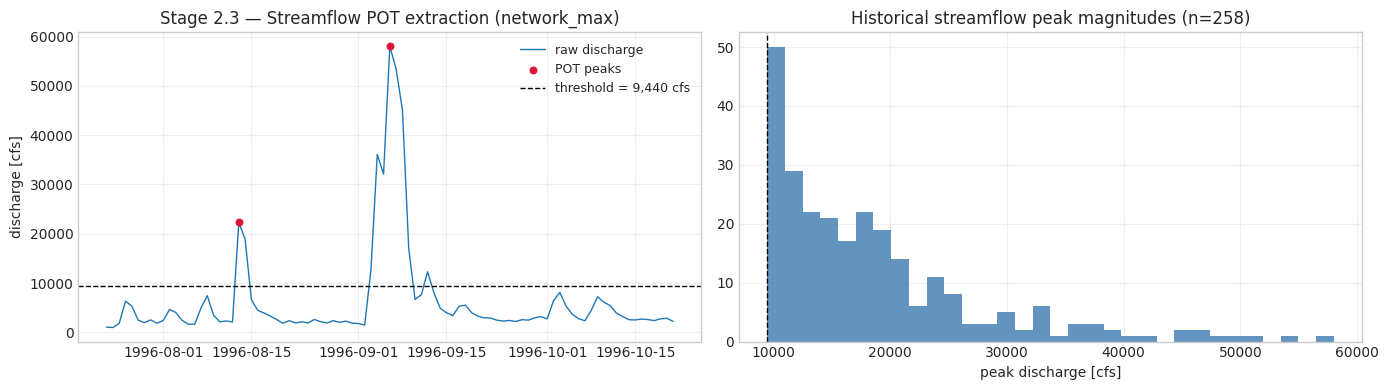

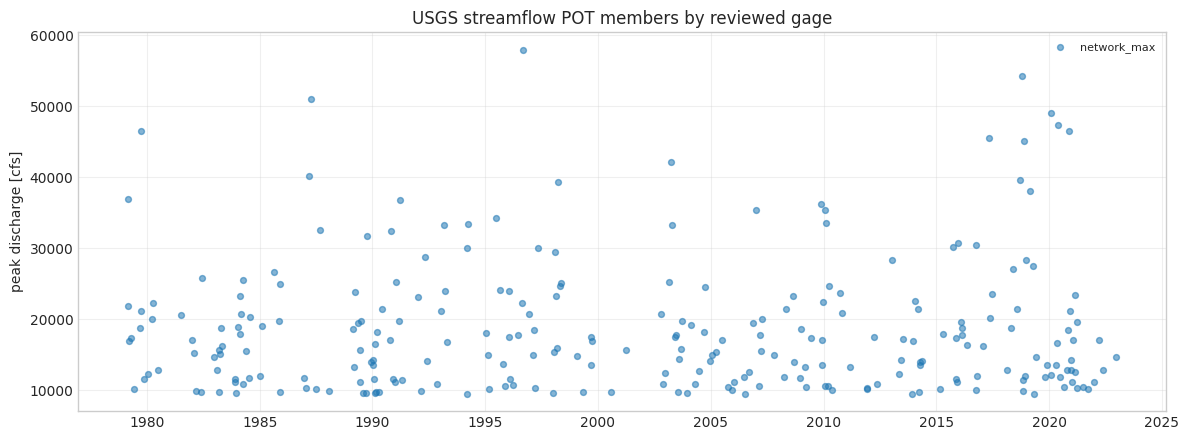

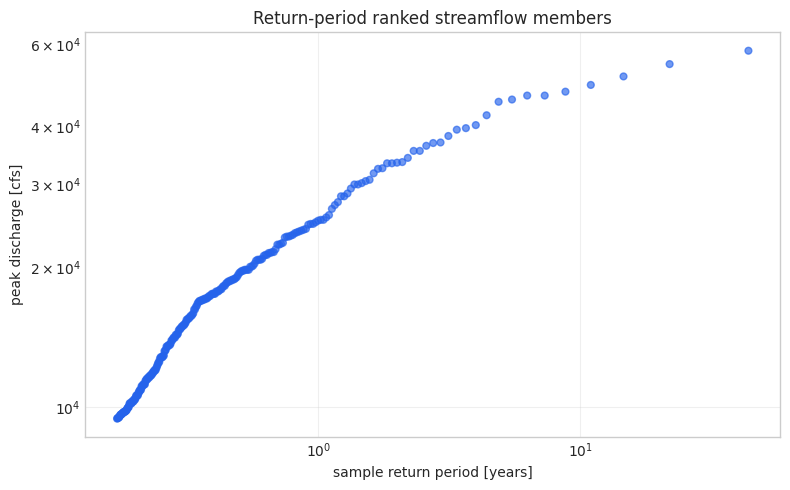

In [5]:
ts_streamflow = df_streamflow["discharge_cfs"].dropna()
threshold_cfs = float(ts_streamflow.quantile(pot_quantile))
extremes = get_extremes(
    ts=ts_streamflow,
    method="POT",
    threshold=threshold_cfs,
    r=min_peak_distance,
)

df_pot = extremes.to_frame(name="peak_flow_cfs").sort_index()
record_years = max((ts_streamflow.index.max() - ts_streamflow.index.min()) / pd.Timedelta(days=365.25), 1.0)
event_rate_per_year = float(dependence.get("event_rate_per_year") or (len(df_pot) / record_years))
streamflow_pot_members = df_pot.assign(
    site_no="network_max",
    event_time=df_pot.index,
    site_threshold_cfs=threshold_cfs,
    rank=lambda frame: frame["peak_flow_cfs"].rank(method="first", ascending=False).astype(int),
)
streamflow_pot_members["sample_rp_years"] = record_years / streamflow_pot_members["rank"]
streamflow_pot_members["sampling_region"] = np.where(streamflow_pot_members["sample_rp_years"] >= 50, "tail", "body")

P.plot_streamflow_pot_extraction(
    network_streamflow_records,
    streamflow_pot_members,
    threshold_quantile=pot_quantile,
    site_no="network_max",
);
P.plot_streamflow_pot_members(streamflow_pot_members);
P.plot_streamflow_return_period_distribution(streamflow_pot_members);

display(pd.Series({
    "threshold_cfs": threshold_cfs,
    "independent_peak_events": len(df_pot),
    "record_years": round(record_years, 2),
    "configured_event_rate_per_year": event_rate_per_year,
}, name="streamflow_pot"))
streamflow_pot_members.head()


### 2.4 AIC Model Selection (Exp vs GPD)

empirical CDF on the left and log-survival tail behavior on the right. The fitted streamflow GPD is used for inverse transformation in the simple inland copula below.


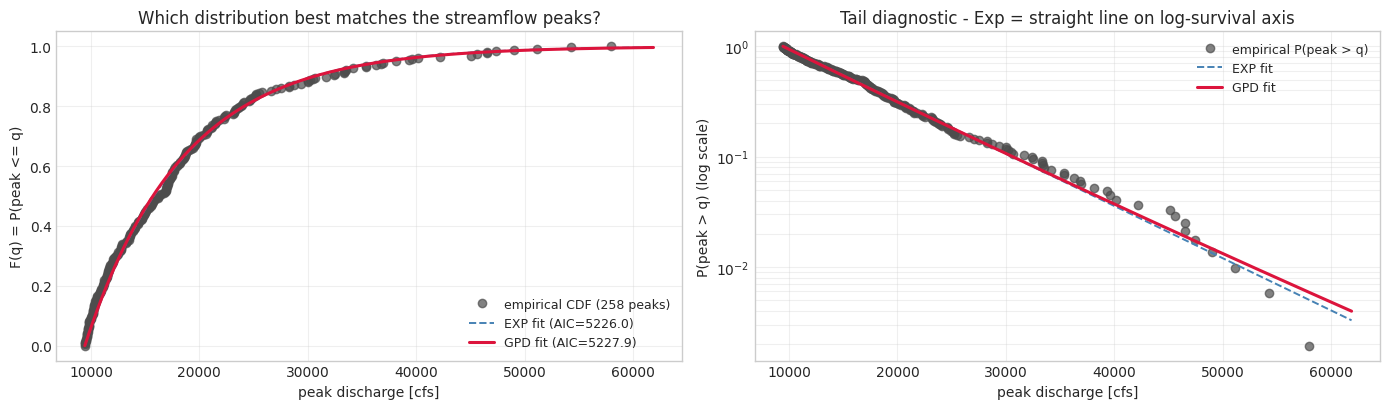

,distribution,aic,shape,scale
0,exp,5225.9584,NaN,9172.3643
1,gpd,5227.8886,0.019,8998.4068


In [6]:
streamflow_exceedances = (df_pot["peak_flow_cfs"] - threshold_cfs).clip(lower=0).to_numpy(dtype=float)
streamflow_exceedances = streamflow_exceedances[np.isfinite(streamflow_exceedances)]

exp_params = stats.expon.fit(streamflow_exceedances, floc=0)
gpd_params = stats.genpareto.fit(streamflow_exceedances, floc=0)

def _aic(log_likelihood, n_params):
    return 2 * n_params - 2 * log_likelihood

exp_aic = _aic(float(np.sum(stats.expon.logpdf(streamflow_exceedances, *exp_params))), 1)
gpd_aic = _aic(float(np.sum(stats.genpareto.logpdf(streamflow_exceedances, *gpd_params))), 2)
shape_sf, loc_sf, scale_sf = gpd_params

sorted_excess = np.sort(streamflow_exceedances)
grid = np.linspace(0, max(sorted_excess.max() * 1.08, 1.0), 400)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(sorted_excess + threshold_cfs, np.linspace(0, 1, len(sorted_excess)), "o", color="0.3", alpha=0.7, label=f"empirical CDF ({len(sorted_excess):,} peaks)")
axes[0].plot(grid + threshold_cfs, stats.expon.cdf(grid, *exp_params), "--", color="steelblue", lw=1.4, label=f"EXP fit (AIC={exp_aic:.1f})")
axes[0].plot(grid + threshold_cfs, stats.genpareto.cdf(grid, *gpd_params), "-", color="crimson", lw=2.2, label=f"GPD fit (AIC={gpd_aic:.1f})")
axes[0].set_xlabel("peak discharge [cfs]")
axes[0].set_ylabel("F(q) = P(peak <= q)")
axes[0].set_title("Which distribution best matches the streamflow peaks?")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].grid(True, alpha=0.3)

n = len(sorted_excess)
emp_surv = 1.0 - (np.arange(1, n + 1) - 0.5) / n
axes[1].semilogy(sorted_excess + threshold_cfs, emp_surv, "o", color="0.3", alpha=0.7, label="empirical P(peak > q)")
axes[1].semilogy(grid + threshold_cfs, stats.expon.sf(grid, *exp_params), "--", color="steelblue", lw=1.4, label="EXP fit")
axes[1].semilogy(grid + threshold_cfs, stats.genpareto.sf(grid, *gpd_params), "-", color="crimson", lw=2.2, label="GPD fit")
axes[1].set_xlabel("peak discharge [cfs]")
axes[1].set_ylabel("P(peak > q) (log scale)")
axes[1].set_title("Tail diagnostic - Exp = straight line on log-survival axis")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()

display(pd.DataFrame([
    {"distribution": "exp", "aic": exp_aic, "shape": np.nan, "scale": exp_params[-1]},
    {"distribution": "gpd", "aic": gpd_aic, "shape": shape_sf, "scale": scale_sf},
]).round(4))


### 2.5 Streamflow Return-period Curve

Trace the fitted streamflow tail into return-period space and overlay the same benchmark return periods used later for design-event coverage.


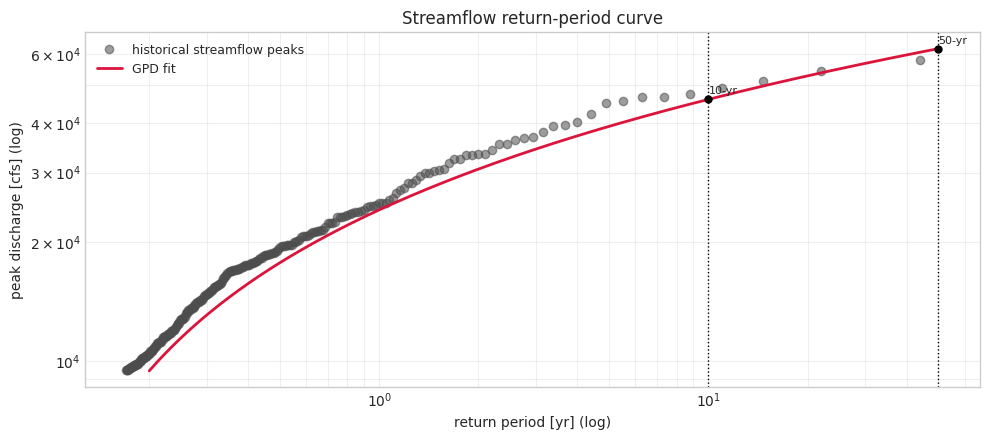

In [7]:
q_grid = grid + threshold_cfs
annual_exceedance = event_rate_per_year * stats.genpareto.sf(grid, c=shape_sf, loc=loc_sf, scale=scale_sf)
rp_grid = 1.0 / np.clip(annual_exceedance, 1e-12, None)
observed = streamflow_pot_members.sort_values("peak_flow_cfs", ascending=True).copy()
observed["observed_rp_years"] = record_years / np.arange(len(observed), 0, -1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(observed["observed_rp_years"], observed["peak_flow_cfs"], "o", color="0.3", alpha=0.55, label="historical streamflow peaks")
ax.plot(rp_grid, q_grid, "-", color="crimson", lw=2, label="GPD fit")
for rp in benchmark_return_periods:
    if min(rp_grid) <= rp <= max(rp_grid):
        q_star = float(np.interp(np.log(rp), np.log(rp_grid), q_grid))
        ax.axvline(rp, ls=":", color="black", lw=1)
        ax.plot([rp], [q_star], "o", color="black", ms=5)
        ax.annotate(f"{int(rp)}-yr", xy=(rp, q_star), xytext=(rp, q_star * 1.03), fontsize=8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("return period [yr] (log)")
ax.set_ylabel("peak discharge [cfs] (log)")
ax.set_title("Streamflow return-period curve")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
plt.show()


### 2.6 Stationarity Diagnostic on Selected Peaks

POT peaks through time with a Theil-Sen slope and a rank-correlation trend test.

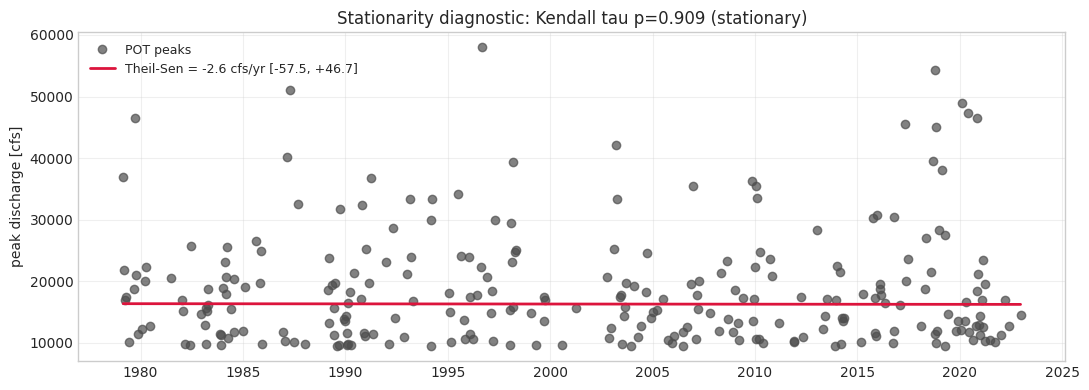

In [8]:
peak_series = df_pot["peak_flow_cfs"].dropna().sort_index()
t_years = ((peak_series.index - peak_series.index.min()) / pd.Timedelta(days=365.25)).to_numpy(dtype=float)
y_peaks = peak_series.to_numpy(dtype=float)
ts_slope = stats.theilslopes(y_peaks, t_years, 0.95)
tau, trend_p = stats.kendalltau(t_years, y_peaks)
line_t = np.array([t_years.min(), t_years.max()])

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(peak_series.index, y_peaks, "o", color="0.3", alpha=0.7, label="POT peaks")
ax.plot(
    [peak_series.index.min(), peak_series.index.max()],
    ts_slope.intercept + ts_slope.slope * line_t,
    "-",
    color="crimson",
    lw=2,
    label=f"Theil-Sen = {ts_slope.slope:+.1f} cfs/yr [{ts_slope.low_slope:+.1f}, {ts_slope.high_slope:+.1f}]",
)
note = "stationary" if trend_p >= 0.05 else "trend detected"
ax.set_title(f"Stationarity diagnostic: Kendall tau p={trend_p:.3f} ({note})")
ax.set_ylabel("peak discharge [cfs]")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Stage 3 - Historical event detection

Pair each streamflow POT event with the maximum rainfall member inside the configured co-occurrence window.Two-sided compound-dependence sample.


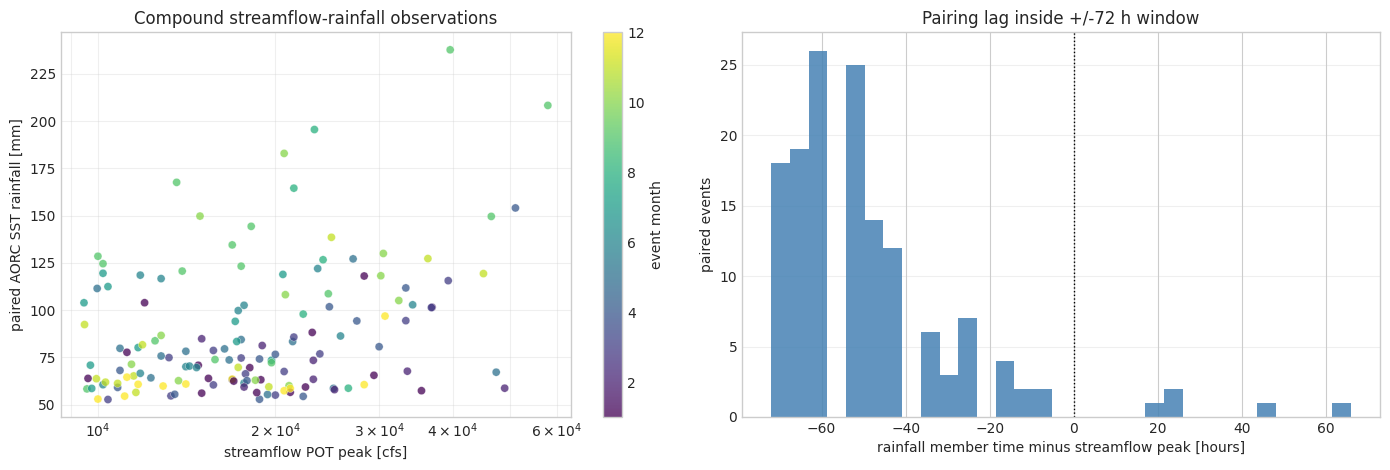

paired_observation_rows    143.0
median_lag_hours           -54.0
p90_abs_lag_hours           72.0
Name: paired_observations, dtype: float64

,streamflow_cfs,concurrent_precip_mm,rainfall_member_time,lag_hours,event_month
event_time,,,,,
1979-02-25,36900.0,101.574148,1979-02-23 00:00:00,-48.0,2
1979-03-24,16900.0,63.271058,1979-03-22 18:00:00,-30.0,3
1979-06-04,10200.0,60.595773,1979-06-01 18:00:00,-54.0,6
1979-09-24,46500.0,149.639189,1979-09-21 00:00:00,-72.0,9
1979-10-04,21100.0,60.063903,1979-10-02 18:00:00,-30.0,10


In [9]:
paired_records = []
for event_time, row in df_pot.iterrows():
    window_start = event_time - cooccurrence_window
    window_end = event_time + cooccurrence_window
    concurrent_window = df_rainfall.loc[window_start:window_end, "precip_mm"]
    if concurrent_window.empty:
        continue
    rainfall_time = concurrent_window.idxmax()
    paired_records.append({
        "event_time": event_time,
        "streamflow_cfs": row["peak_flow_cfs"],
        "concurrent_precip_mm": float(concurrent_window.loc[rainfall_time]),
        "rainfall_member_time": rainfall_time,
        "lag_hours": (rainfall_time - event_time) / pd.Timedelta(hours=1),
        "event_month": int(pd.Timestamp(event_time).month),
    })

df_paired = pd.DataFrame(paired_records).set_index("event_time").dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
scatter = axes[0].scatter(
    df_paired["streamflow_cfs"],
    df_paired["concurrent_precip_mm"],
    c=df_paired["event_month"],
    cmap="viridis",
    s=34,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3,
)
axes[0].set_xscale("log")
axes[0].set_xlabel("streamflow POT peak [cfs]")
axes[0].set_ylabel("paired AORC SST rainfall [mm]")
axes[0].set_title("Compound streamflow-rainfall observations")
axes[0].grid(True, alpha=0.3, which="both")
plt.colorbar(scatter, ax=axes[0], label="event month")
axes[1].hist(df_paired["lag_hours"], bins=31, color="steelblue", alpha=0.85)
axes[1].axvline(0, color="black", ls=":", lw=1)
axes[1].set_xlabel("rainfall member time minus streamflow peak [hours]")
axes[1].set_ylabel("paired events")
axes[1].set_title(f"Pairing lag inside +/-{cooccurrence_window / pd.Timedelta(hours=1):.0f} h window")
axes[1].grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

display(pd.Series({
    "paired_observation_rows": len(df_paired),
    "median_lag_hours": float(df_paired["lag_hours"].median()),
    "p90_abs_lag_hours": float(df_paired["lag_hours"].abs().quantile(0.90)),
}, name="paired_observations"))
df_paired.head()


## Stage 4 - Two-sided POT co-occurrence and dependence vector

Fit the streamflow GPD tail and map rainfall through its empirical CDF. The PIT histograms and uniform scatter show marginal and copula-fit diagnostics.


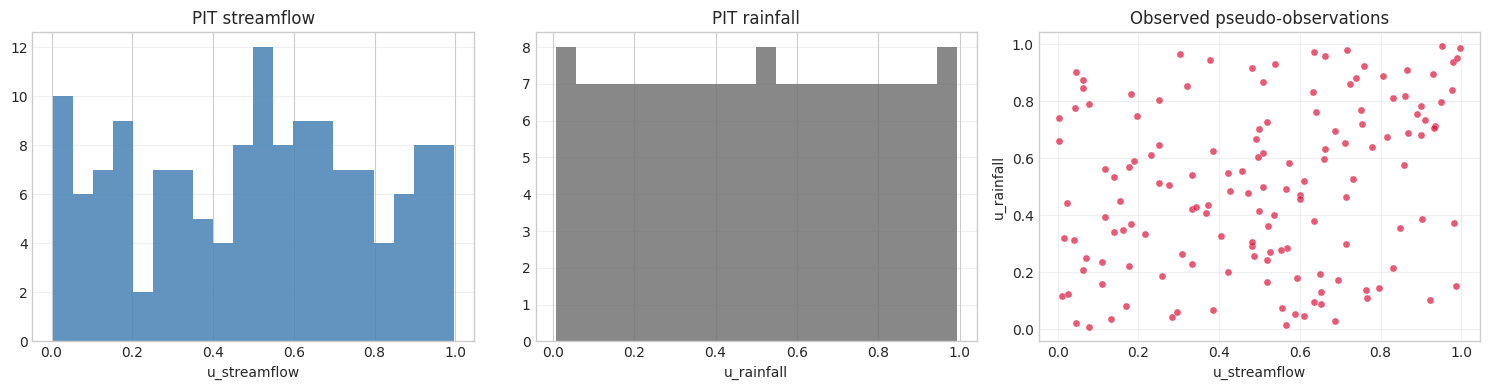

streamflow_gpd_shape        -0.118365
streamflow_gpd_scale     11818.005917
rainfall_marginal       empirical_cdf
Name: marginal_fit, dtype: object

In [10]:
paired_exceedances = (df_paired["streamflow_cfs"] - threshold_cfs).clip(lower=0)
shape_sf, loc_sf, scale_sf = stats.genpareto.fit(paired_exceedances, floc=0)
u_streamflow = stats.genpareto.cdf(paired_exceedances, c=shape_sf, loc=loc_sf, scale=scale_sf)
u_rainfall = df_paired["concurrent_precip_mm"].rank(method="average").to_numpy(dtype=float) / (len(df_paired) + 1)
u_data = np.clip(np.column_stack([u_streamflow, u_rainfall]), 1e-6, 1 - 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(u_data[:, 0], bins=20, color="steelblue", alpha=0.85)
axes[0].set_title("PIT streamflow")
axes[0].set_xlabel("u_streamflow")
axes[0].grid(True, alpha=0.3, axis="y")
axes[1].hist(u_data[:, 1], bins=20, color="0.45", alpha=0.85)
axes[1].set_title("PIT rainfall")
axes[1].set_xlabel("u_rainfall")
axes[1].grid(True, alpha=0.3, axis="y")
axes[2].scatter(u_data[:, 0], u_data[:, 1], s=26, alpha=0.7, color="crimson", edgecolor="white", linewidth=0.3)
axes[2].set_xlabel("u_streamflow")
axes[2].set_ylabel("u_rainfall")
axes[2].set_title("Observed pseudo-observations")
axes[2].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "streamflow_gpd_shape": shape_sf,
    "streamflow_gpd_scale": scale_sf,
    "rainfall_marginal": "empirical_cdf",
}, name="marginal_fit"))


## Stage 5 - Copula-joint AND design catalog

Fit a bivariate copula to the uniform streamflow-rainfall observations. Observed-vs-fitted dependence check.

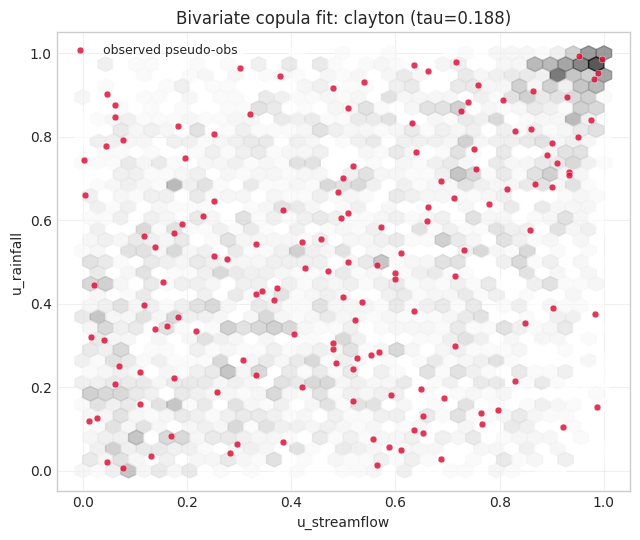

copula_family                     clayton
copula_parameters    [0.4640322821012683]
kendall_tau                      0.188322
Name: copula_fit, dtype: object

In [11]:
controls = pvc.FitControlsBicop(
    family_set=[
        pvc.BicopFamily.gumbel,
        pvc.BicopFamily.clayton,
        pvc.BicopFamily.frank,
        pvc.BicopFamily.gaussian,
        pvc.BicopFamily.student,
    ],
    selection_criterion="bic",
)
copula = pvc.Bicop.from_data(data=u_data, controls=controls)
fitted_u = np.asarray(copula.simulate(4000, seeds=[copula_seed + 1]), dtype=float)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.hexbin(fitted_u[:, 0], fitted_u[:, 1], gridsize=34, extent=(0, 1, 0, 1), mincnt=1, cmap="Greys", alpha=0.65)
ax.scatter(u_data[:, 0], u_data[:, 1], s=24, alpha=0.85, color="crimson", edgecolor="white", linewidth=0.3, label="observed pseudo-obs")
ax.set_xlabel("u_streamflow")
ax.set_ylabel("u_rainfall")
ax.set_title(f"Bivariate copula fit: {copula.family.name} (tau={copula.tau:.3f})")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

display(pd.Series({
    "copula_family": copula.family.name,
    "copula_parameters": np.asarray(copula.parameters).ravel().tolist(),
    "kendall_tau": copula.tau,
}, name="copula_fit"))


### 5.1 Historical Driver Severity Distribution

Before selecting synthetic design events, check how the observed paired driver record falls across the same AND return-period severity bands. This is an empirical driver-space diagnostic, not the selected resilience set.


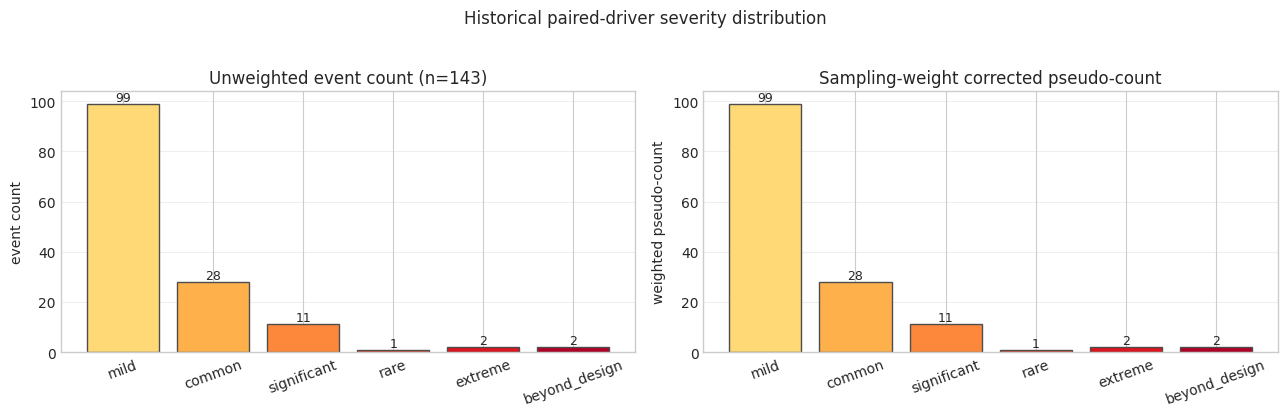

historical_paired_events                                                   143
driver_vector                                             streamflow, rainfall
severity_basis                       empirical paired-driver AND return period
median_historical_driver_rp_years                                     0.889286
max_historical_driver_rp_years                                     4007.263493
Name: historical_driver_severity, dtype: object

In [12]:
historical_joint_survival = np.clip((1 - u_data[:, 0]) * (1 - u_data[:, 1]), 1e-12, None)
historical_driver_rp = 1.0 / np.clip(event_rate_per_year * historical_joint_survival, 1e-12, None)
historical_driver_severity = df_paired.reset_index().copy()
historical_driver_severity["sample_rp_years"] = historical_driver_rp
historical_driver_severity["severity_band"] = assign_severity_bands(
    historical_driver_severity["sample_rp_years"],
    config["sampling"]["severity_bands"],
)
historical_driver_severity["sampling_weight"] = 1.0

fig = P.plot_severity_bands(historical_driver_severity)
fig.suptitle("Historical paired-driver severity distribution", y=1.03)
plt.show()

display(pd.Series({
    "historical_paired_events": len(historical_driver_severity),
    "driver_vector": "streamflow, rainfall",
    "severity_basis": "empirical paired-driver AND return period",
    "median_historical_driver_rp_years": float(np.nanmedian(historical_driver_severity["sample_rp_years"])),
    "max_historical_driver_rp_years": float(np.nanmax(historical_driver_severity["sample_rp_years"])),
}, name="historical_driver_severity"))


## Stage 6 - Vine fit and AND joint-exceedance diagnostics

Simulate from the fitted copula, invert the marginal transforms back to physical units, and label rows by an AND-style joint return period. The contour plot follows benchmark-isoline convention adapted to the simple inland bivariate model.

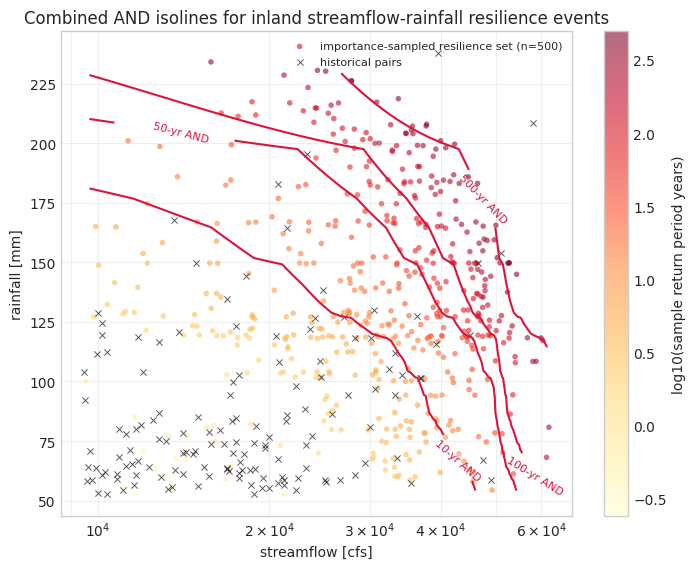

candidate_pool_rows                                                    100000
selected_resilience_rows                                                  500
sampling_scheme                                    band_stratified_importance
target_band_counts          {'mild': 25, 'common': 140, 'significant': 140...
Name: importance_sampled_resilience_set, dtype: object

In [13]:
candidate_pool_count = int(dependence.get("pool_size", 100000))
u_pool = np.asarray(copula.simulate(n=candidate_pool_count, seeds=[copula_seed]), dtype=float)
u_pool = np.clip(u_pool, 1e-6, 1 - 1e-6)
pool_streamflow = stats.genpareto.ppf(u_pool[:, 0], c=shape_sf, loc=loc_sf, scale=scale_sf) + threshold_cfs

rain_vals = np.sort(df_paired["concurrent_precip_mm"].to_numpy(dtype=float))
rain_probs = np.linspace(0, 1, len(rain_vals))
inv_ecdf_rain = interp1d(rain_probs, rain_vals, bounds_error=False, fill_value=(rain_vals.min(), rain_vals.max()))
pool_rainfall = inv_ecdf_rain(u_pool[:, 1])

pool_joint_survival = np.clip((1 - u_pool[:, 0]) * (1 - u_pool[:, 1]), 1e-12, None)
pool_sample_rp_years = 1.0 / np.clip(event_rate_per_year * pool_joint_survival, 1e-12, None)
pool_severity_band = assign_severity_bands(pool_sample_rp_years, config["sampling"]["severity_bands"])

candidate_catalog = pd.DataFrame({
    "event_id": [f"candidate_{i:06d}" for i in range(candidate_pool_count)],
    "catalog_role": "candidate_pool",
    "scenario_name": "base",
    "u_streamflow": u_pool[:, 0],
    "u_rainfall": u_pool[:, 1],
    "streamflow_cfs": pool_streamflow,
    "peak_flow_cfs": pool_streamflow,
    "basis_site_no": "network_max",
    "rainfall_mm": pool_rainfall,
    "sample_rp_years": pool_sample_rp_years,
    "severity_band": pool_severity_band,
})
candidate_catalog["sampling_weight"] = 1.0
candidate_catalog["probability_weight"] = 1.0 / len(candidate_catalog)

severity_fractions = resilience_stress_training["severity_band_fractions"]
band_order = [band["severity_band"] for band in config["sampling"]["severity_bands"]]
target_counts = {
    band: int(np.floor(target_design_events * float(severity_fractions.get(band, 0.0))))
    for band in band_order
}
remainder = target_design_events - sum(target_counts.values())
remainder_order = sorted(
    target_counts,
    key=lambda band: target_design_events * float(severity_fractions.get(band, 0.0)) - target_counts[band],
    reverse=True,
)
for band in remainder_order[: max(remainder, 0)]:
    target_counts[band] += 1

rng = np.random.default_rng(copula_seed)
selected_indices = []
band_probability = candidate_catalog["severity_band"].astype(str).value_counts(normalize=True).to_dict()
for band in band_order:
    n_band = int(target_counts.get(band, 0))
    if n_band <= 0:
        continue
    members = candidate_catalog.index[candidate_catalog["severity_band"].astype(str).eq(str(band))].to_numpy()
    if len(members) == 0:
        raise ValueError(f"candidate pool has no events in severity band {band!r}; increase candidate_pool_count")
    selected_indices.extend(rng.choice(members, size=n_band, replace=len(members) < n_band).tolist())

rng.shuffle(selected_indices)
df_catalog = candidate_catalog.loc[selected_indices].reset_index(drop=True).copy()
df_catalog["event_id"] = [f"design_{i:04d}" for i in range(len(df_catalog))]
df_catalog["catalog_role"] = "design"
df_catalog["event_set"] = "resilience_stress_training"
df_catalog["selection_role"] = "resilience_stress_training"
df_catalog["selection_reason"] = "band_stratified_importance"
df_catalog["sampling_scheme"] = "band_stratified_importance"
df_catalog["candidate_pool_count"] = candidate_pool_count
df_catalog["pool_band_probability"] = df_catalog["severity_band"].astype(str).map(band_probability).astype(float)
df_catalog["target_band_fraction"] = df_catalog["severity_band"].astype(str).map(severity_fractions).astype(float)
df_catalog["sampling_weight"] = df_catalog["pool_band_probability"] / df_catalog["target_band_fraction"]
df_catalog["probability_weight"] = df_catalog["sampling_weight"] / df_catalog["sampling_weight"].sum()

u_axis = np.linspace(0.02, 0.998, 90)
u_stream_grid, u_rain_grid = np.meshgrid(u_axis, u_axis)
x_grid = stats.genpareto.ppf(u_stream_grid, c=shape_sf, loc=loc_sf, scale=scale_sf) + threshold_cfs
y_grid = inv_ecdf_rain(u_rain_grid)
rp_grid = 1.0 / np.clip(event_rate_per_year * (1 - u_stream_grid) * (1 - u_rain_grid), 1e-12, None)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
points = ax.scatter(
    df_catalog["streamflow_cfs"],
    df_catalog["rainfall_mm"],
    c=np.log10(df_catalog["sample_rp_years"].clip(lower=1e-3)),
    cmap="YlOrRd",
    s=16,
    alpha=0.58,
    edgecolor="none",
    label=f"importance-sampled resilience set (n={len(df_catalog):,})",
)
contour = ax.contour(x_grid, y_grid, rp_grid, levels=sorted(benchmark_return_periods), colors="crimson", linewidths=1.5)
ax.clabel(contour, inline=True, fontsize=8, fmt=lambda value: f"{value:g}-yr AND")
ax.scatter(df_paired["streamflow_cfs"], df_paired["concurrent_precip_mm"], s=20, color="black", marker="x", linewidths=0.7, alpha=0.65, label="historical pairs")
ax.set_xscale("log")
ax.set_xlabel("streamflow [cfs]")
ax.set_ylabel("rainfall [mm]")
ax.set_title("Combined AND isolines for inland streamflow-rainfall resilience events")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3, which="both")
plt.colorbar(points, ax=ax, label="log10(sample return period years)")
fig.tight_layout()
plt.show()

pd.Series({
    "candidate_pool_rows": len(candidate_catalog),
    "selected_resilience_rows": len(df_catalog),
    "sampling_scheme": df_catalog["sampling_scheme"].iloc[0],
    "target_band_counts": target_counts,
}, name="importance_sampled_resilience_set")


## Stage 7 - Wflow readiness replay set

Severity-band coverage, benchmark return-period coverage, and row previews.

### 7.1 Selected Design Catalog Severity Ranges

These severity labels are keyed to pre-SFINCS AND return period from the fitted copula, not to flood-response AEP. The configured return-period ranges are shown first so the labels are concrete before plotting the design catalog.


,severity_band,and_joint_return_period_range,annual_chance_range
0,mild,0 to <2 yr,> 50%
1,common,2 to <10 yr,> 10% to <= 50%
2,significant,10 to <50 yr,> 2% to <= 10%
3,rare,50 to <100 yr,> 1% to <= 2%
4,extreme,100 to <500 yr,> 0.2% to <= 1%
5,beyond_design,>= 500 yr,<= 0.2%


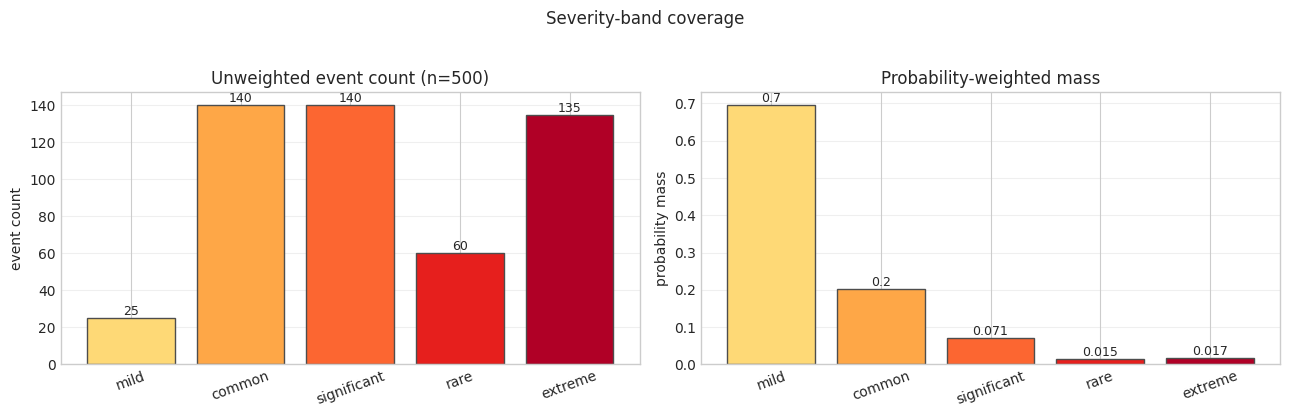

In [14]:
severity_ranges = pd.DataFrame(config["sampling"]["severity_bands"])
severity_ranges["and_joint_return_period_range"] = severity_ranges.apply(
    lambda row: (
        f">= {row['rp_min_years']:g} yr" if pd.isna(row["rp_max_years"])
        else f"{row['rp_min_years']:g} to <{row['rp_max_years']:g} yr"
    ),
    axis=1,
)
severity_ranges["annual_chance_range"] = severity_ranges.apply(
    lambda row: (
        f"<= {100 / row['rp_min_years']:g}%" if pd.isna(row["rp_max_years"]) and row["rp_min_years"] > 0
        else (
            f"> {100 / row['rp_max_years']:g}% to <= {100 / row['rp_min_years']:g}%"
            if row["rp_min_years"] > 0 else f"> {100 / row['rp_max_years']:g}%"
        )
    ),
    axis=1,
)
display(severity_ranges[["severity_band", "and_joint_return_period_range", "annual_chance_range"]])
P.plot_severity_bands(df_catalog);


### 7.2 Resilience Stress/Training Coverage

The final resilience set is a 500-event band-stratified importance sample from the fitted candidate pool. Unweighted counts show the modeling/run budget allocation; probability-weighted mass shows the fitted joint probability represented by those enriched rows.


candidate_pool_rows                             100000
stress_training_rows                               500
sampling_scheme             band_stratified_importance
mild_rows                                           25
mild_fraction                                     0.05
probability_weight_sum                             1.0
benchmark_return_periods            [10, 50, 100, 500]
Name: resilience_stress_training, dtype: object

,event_id,sample_rp_years,severity_band,sampling_weight,probability_weight,streamflow_cfs,rainfall_mm
498,design_0498,10.01,significant,0.252,0.000510,28996.0,123.5
378,design_0378,50.13,rare,0.120,0.000242,29458.0,171.5
42,design_0042,49.72,significant,0.252,0.000510,39793.0,129.7
394,design_0394,100.61,extreme,0.062,0.000126,43919.0,138.1
282,design_0282,10.06,significant,0.252,0.000510,40784.0,76.6
492,design_0492,496.33,extreme,0.062,0.000126,54332.0,145.0
325,design_0325,496.05,extreme,0.062,0.000126,49977.0,165.6
70,design_0070,9.92,common,0.713,0.001442,45529.0,58.1
435,design_0435,49.43,significant,0.252,0.000510,37075.0,145.0
154,design_0154,101.19,extreme,0.062,0.000126,36275.0,168.4


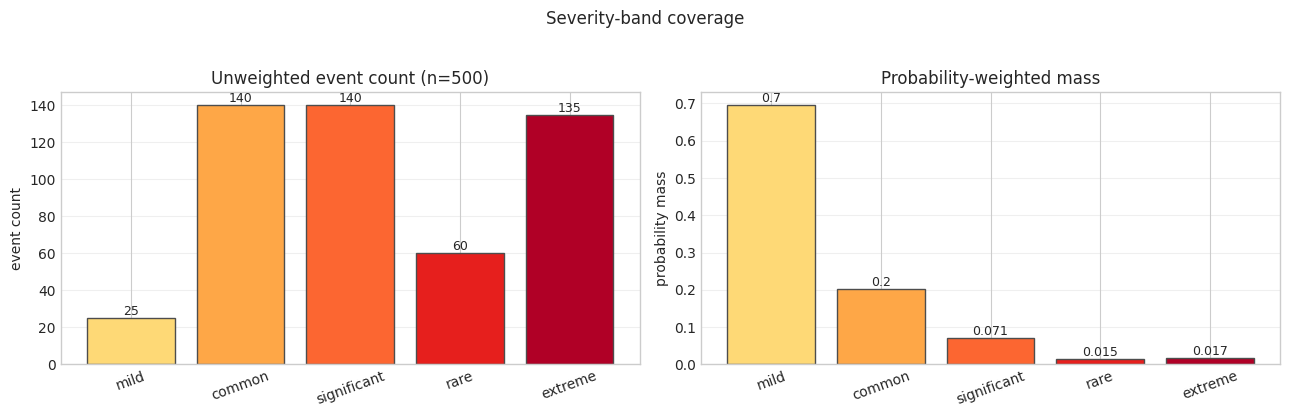

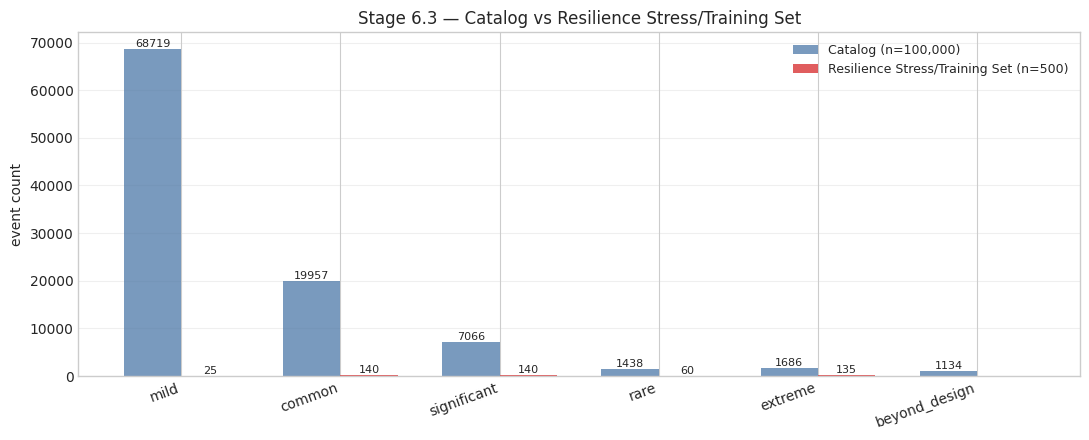

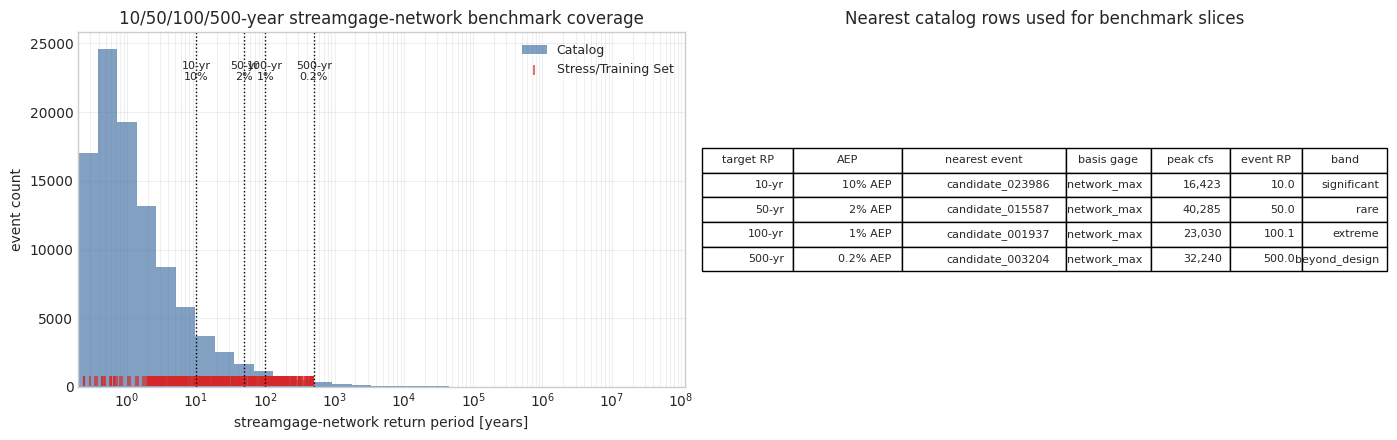

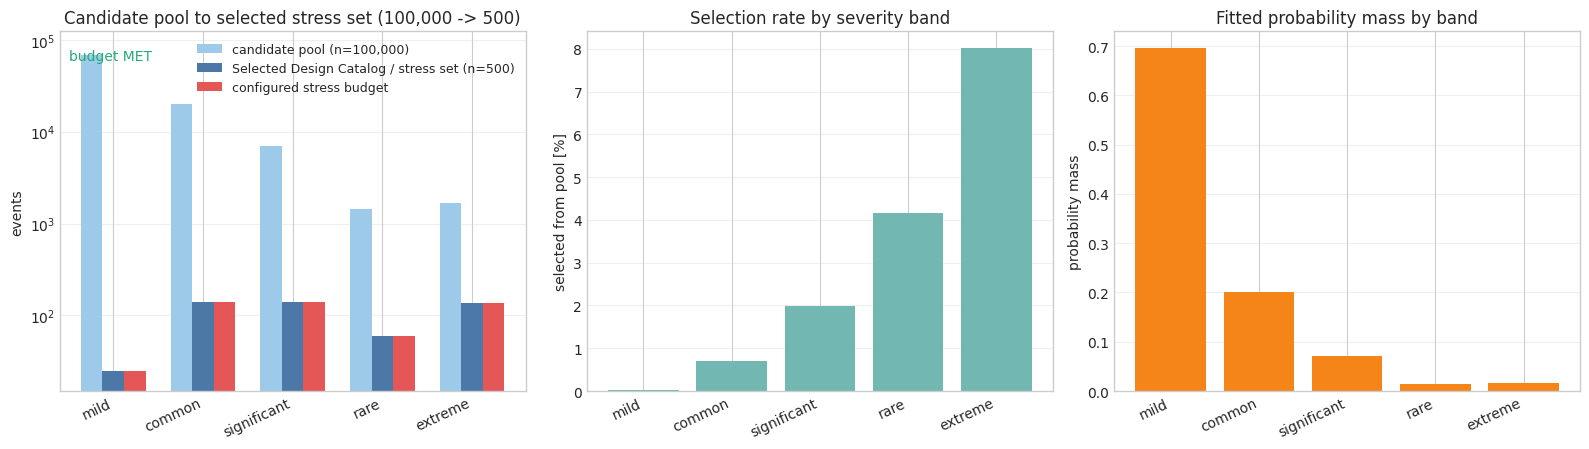

In [15]:
stress_training_catalog = df_catalog.copy()
P.plot_severity_bands(stress_training_catalog);
P.plot_catalog_set_severity_comparison(candidate_catalog, stress_training_catalog);
P.plot_return_period_benchmark_coverage(
    candidate_catalog,
    stress_catalog=stress_training_catalog,
    benchmarks=benchmark_return_periods,
);
P.plot_joint_tail_budget(stress_training_catalog, resilience_stress_training, severity_bands=config["sampling"]["severity_bands"]);

stress_summary = pd.Series({
    "candidate_pool_rows": len(candidate_catalog),
    "stress_training_rows": len(stress_training_catalog),
    "sampling_scheme": stress_training_catalog["sampling_scheme"].iloc[0],
    "mild_rows": int((stress_training_catalog["severity_band"] == "mild").sum()),
    "mild_fraction": float((stress_training_catalog["severity_band"] == "mild").mean()),
    "probability_weight_sum": float(stress_training_catalog["probability_weight"].sum()),
    "benchmark_return_periods": benchmark_return_periods,
}, name="resilience_stress_training")
display(stress_summary)

stress_preview = stress_training_catalog.assign(
    benchmark_distance=lambda frame: frame["sample_rp_years"].apply(
        lambda value: min(abs(np.log(value) - np.log(rp)) for rp in benchmark_return_periods)
    )
).sort_values(["benchmark_distance", "sample_rp_years"])
display(stress_preview[[
    "event_id", "sample_rp_years", "severity_band", "sampling_weight", "probability_weight",
    "streamflow_cfs", "rainfall_mm",
]].head(16).round({"sample_rp_years": 2, "sampling_weight": 3, "probability_weight": 8, "streamflow_cfs": 0, "rainfall_mm": 1}))


## Stage 8 - Hand off to Wflow and SFINCS

Each design row is matched to the closest observed streamflow POT analog and closest rainfall member, then gets scale factors that downstream model builders can use to preserve observed temporal fields while scaling their magnitudes.


,event_id,catalog_role,scenario_name,sample_rp_years,severity_band,sampling_scheme,sampling_weight,probability_weight,streamflow_cfs,streamflow_member_id,streamflow_scale_factor,rainfall_mm,rainfall_member_id,rainfall_scale_factor,forcing_pairing_policy,event_drivers
0,design_0000,design,base,141.90,extreme,band_stratified_importance,0.062,0.000126,45190.0,streamflow_20181113T000000,1.002,147.2,rainfall_greensboro_72h_rank0014,0.984,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"
1,design_0001,design,base,2.55,common,band_stratified_importance,0.713,0.001442,15912.0,streamflow_19980310T000000,1.001,121.2,rainfall_greensboro_72h_rank0034,1.004,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"
2,design_0002,design,base,10.30,significant,band_stratified_importance,0.252,0.000510,35081.0,streamflow_20070102T000000,0.991,105.6,rainfall_greensboro_72h_rank0063,0.999,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"
3,design_0003,design,base,6.62,common,band_stratified_importance,0.713,0.001442,37698.0,streamflow_20190225T000000,0.989,74.6,rainfall_greensboro_72h_rank0182,0.998,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"
4,design_0004,design,base,21.90,significant,band_stratified_importance,0.252,0.000510,39567.0,streamflow_20180917T000000,0.999,116.8,rainfall_greensboro_72h_rank0046,1.000,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"
5,design_0005,design,base,395.62,extreme,band_stratified_importance,0.062,0.000126,39980.0,streamflow_19870303T000000,0.995,201.1,rainfall_greensboro_72h_rank0003,1.028,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"
6,design_0006,design,base,195.38,extreme,band_stratified_importance,0.062,0.000126,39372.0,streamflow_19980319T000000,1.002,183.6,rainfall_greensboro_72h_rank0004,0.998,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"
7,design_0007,design,base,4.63,common,band_stratified_importance,0.713,0.001442,26287.0,streamflow_19850820T000000,0.988,112.4,rainfall_greensboro_72h_rank0051,0.999,streamflow_frequency_axis_with_aorc_sst_rainfall,"streamflow,rainfall"


event_catalog_rows                                                              500
event_catalog_csv                 /home/grahamhults/projects/Flood-RM/locations/...
resilience_stress_training_csv    /home/grahamhults/projects/Flood-RM/locations/...
streamflow_analog_count                                                         110
rainfall_analog_count                                                           141
Name: event_catalog_handoff, dtype: object

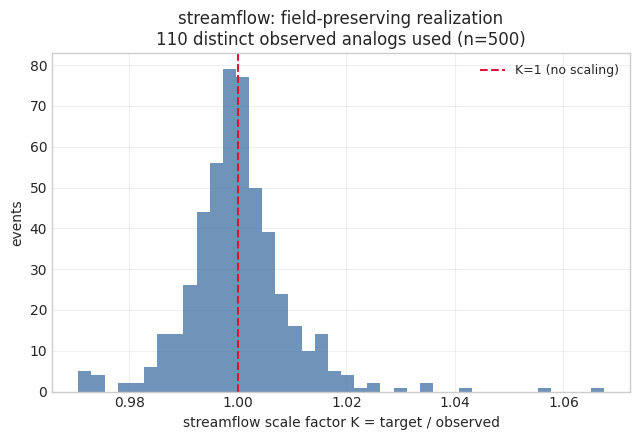

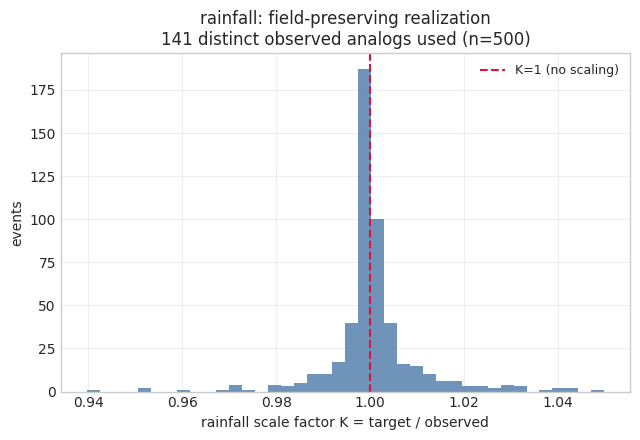

In [16]:
historical_peaks = df_pot["peak_flow_cfs"].to_numpy(dtype=float)
historical_times = df_pot.index
rainfall_member_values = rainfall_members[rainfall_value_column].to_numpy(dtype=float)
rainfall_member_ids = rainfall_members.get("member_id", pd.Series(rainfall_members.index.astype(str))).astype(str).to_numpy()

analog_indices = []
streamflow_scale_factors = []
rainfall_member_indices = []
rainfall_scale_factors = []

for _, row in df_catalog.iterrows():
    streamflow_best_idx = int(np.argmin(np.abs(historical_peaks - row["streamflow_cfs"])))
    rainfall_best_idx = int(np.nanargmin(np.abs(rainfall_member_values - row["rainfall_mm"])))
    analog_indices.append(historical_times[streamflow_best_idx])
    streamflow_scale_factors.append(row["streamflow_cfs"] / max(historical_peaks[streamflow_best_idx], 1e-9))
    rainfall_member_indices.append(rainfall_best_idx)
    rainfall_scale_factors.append(row["rainfall_mm"] / max(rainfall_member_values[rainfall_best_idx], 1e-9))

df_catalog["event_reference_time"] = pd.to_datetime(analog_indices)
df_catalog["analog_event_time"] = df_catalog["event_reference_time"]
df_catalog["streamflow_template_member_id"] = "streamflow_" + df_catalog["event_reference_time"].dt.strftime("%Y%m%dT%H%M%S")
df_catalog["streamflow_member_id"] = df_catalog["streamflow_template_member_id"]
df_catalog["streamflow_scale_factor"] = streamflow_scale_factors
df_catalog["rainfall_member_id"] = rainfall_member_ids[rainfall_member_indices]
df_catalog["rainfall_template_member_id"] = df_catalog["rainfall_member_id"]
df_catalog["rainfall_scale_factor"] = rainfall_scale_factors
df_catalog["forcing_pairing_policy"] = "streamflow_frequency_axis_with_aorc_sst_rainfall"
df_catalog["event_drivers"] = "streamflow,rainfall"
stress_training_catalog = df_catalog.copy()

P.plot_realization_scaling(df_catalog, "streamflow");
P.plot_realization_scaling(df_catalog, "rainfall");

output_catalog_csv.parent.mkdir(parents=True, exist_ok=True)
df_catalog.to_csv(output_catalog_csv, index=False)
paths["resilience_stress_training_catalog_csv"].parent.mkdir(parents=True, exist_ok=True)
stress_training_catalog.to_csv(paths["resilience_stress_training_catalog_csv"], index=False)

catalog_preview_columns = [
    "event_id", "catalog_role", "scenario_name", "sample_rp_years", "severity_band",
    "sampling_scheme", "sampling_weight", "probability_weight", "streamflow_cfs",
    "streamflow_member_id", "streamflow_scale_factor", "rainfall_mm", "rainfall_member_id",
    "rainfall_scale_factor", "forcing_pairing_policy", "event_drivers",
]
display(df_catalog[catalog_preview_columns].head(8).round({
    "sample_rp_years": 2,
    "sampling_weight": 3,
    "probability_weight": 8,
    "streamflow_cfs": 0,
    "streamflow_scale_factor": 3,
    "rainfall_mm": 1,
    "rainfall_scale_factor": 3,
}))
display(pd.Series({
    "event_catalog_rows": len(df_catalog),
    "event_catalog_csv": str(output_catalog_csv),
    "resilience_stress_training_csv": str(paths["resilience_stress_training_catalog_csv"]),
    "streamflow_analog_count": df_catalog["streamflow_template_member_id"].nunique(),
    "rainfall_analog_count": df_catalog["rainfall_member_id"].nunique(),
}, name="event_catalog_handoff"))
